Loaded 5000 rows from C:\Users\Hp\Python\2026 Python\2026 JOB5 Attention based noise\preds_test_L128.csv
Saved overall (macro) metrics ? C:\Users\Hp\Python\2026 Python\2026 JOB5 Attention based noise\preds_summary_L128_overall.csv


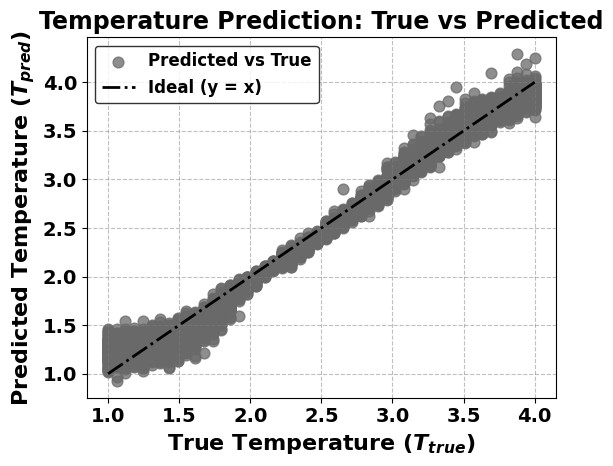

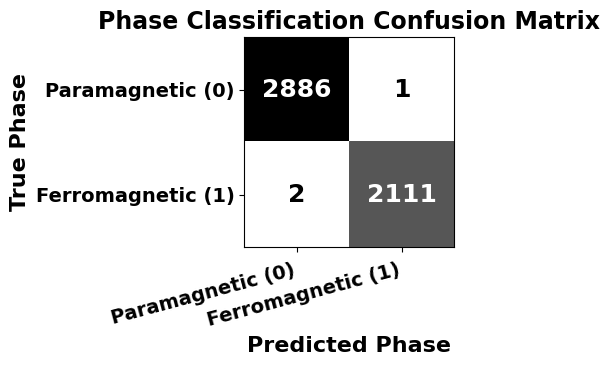

Saved combined plots ? C:\Users\Hp\Python\2026 Python\2026 JOB5 Attention based noise\preds_test_L128_plots.pdf
Saved standalone confusion matrix ? C:\Users\Hp\Python\2026 Python\2026 JOB5 Attention based noise\preds_test_L128_confusion_matrix.pdf
Metrics summary saved ? C:\Users\Hp\Python\2026 Python\2026 JOB5 Attention based noise\preds_summary_L128_overall.csv
Temperature MAE (info): 0.088371


In [8]:
# -*- coding: utf-8 -*-
"""
Display and save grayscale evaluation plots for preds_test_L{L}.csv.

Outputs (saved in same folder as CSV):
  - preds_test_L{L}_plots.pdf            (scatter + confusion matrix)
  - preds_test_L{L}_confusion_matrix.pdf (confusion matrix only)
  - preds_summary_L{L}_overall.csv       (Phase Accuracy, Precision, Recall, F1)
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, accuracy_score,
    precision_recall_fscore_support
)

# =========================
# USER CONFIGURATION
# =========================
import os

L = 128  # change this to 64 or 128 as needed

BASE_NAME = f"preds_test_L{L}"

# Directory where the notebook / code is running
SCRIPT_DIR = os.getcwd()

# Paths (read and save in same directory)
CSV_PATH = os.path.join(SCRIPT_DIR, f"{BASE_NAME}.csv")
PDF_PATH = os.path.join(SCRIPT_DIR, f"{BASE_NAME}_plots.pdf")
CONF_PDF_PATH = os.path.join(SCRIPT_DIR, f"{BASE_NAME}_confusion_matrix.pdf")
SUMMARY_CSV = os.path.join(SCRIPT_DIR, f"preds_summary_L{L}_overall.csv")

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows from {CSV_PATH}")

required_cols = {"T_true", "T_pred", "Phase_true", "Phase_pred"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

# =========================
# METRICS (overall, not per class)
# =========================
# Temperature regression metric (kept for info; not saved here)
mae_T = mean_absolute_error(df["T_true"], df["T_pred"])

# Phase classification (macro metrics)
y_true = df["Phase_true"].to_numpy()
y_pred = df["Phase_pred"].to_numpy()

acc_phase = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)

# Save overall summary CSV (only overall metrics)
summary = pd.DataFrame([{
    "Phase_Accuracy": acc_phase,
    "Precision": prec_macro,
    "Recall": rec_macro,
    "F1_Score": f1_macro
}])
summary.to_csv(SUMMARY_CSV, index=False)
print(f"Saved overall (macro) metrics ? {SUMMARY_CSV}")

# =========================
# STYLE SETTINGS (grayscale + bold)
# =========================
plt.rcParams.update({
    "font.size": 18,
    "font.weight": "bold",
    "axes.labelsize": 16,
    "axes.labelweight": "bold",
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "lines.linewidth": 2.2,
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "legend.fontsize": 12
})

# =========================
# PLOTS — DISPLAY + SAVE (combined PDF)
# =========================
with PdfPages(PDF_PATH) as pdf:

    # 1) Temperature: Predicted vs True (scatter)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df["T_true"], df["T_pred"],
               color="dimgray", s=60, alpha=0.75,
               label="Predicted vs True")

    lo, hi = float(df["T_true"].min()), float(df["T_true"].max())
    ax.plot([lo, hi], [lo, hi], linestyle="-.", color="black", lw=2,
            label="Ideal (y = x)")

    ax.set_xlabel("True Temperature ($T_{true}$)", fontweight="bold")
    ax.set_ylabel("Predicted Temperature ($T_{pred}$)", fontweight="bold")
    ax.set_title("Temperature Prediction: True vs Predicted", fontweight="bold")

    leg = ax.legend(facecolor="white", edgecolor="black")
    for t in leg.get_texts():
        t.set_fontweight("bold")

    ax.grid(True, linestyle="--", color="gray", alpha=0.5)
    ax.tick_params(axis="both", which="major", labelsize=14)

    plt.tight_layout()
    plt.show()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # 2) Phase Classification: Confusion Matrix (grayscale)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Paramagnetic (0)", "Ferromagnetic (1)"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Greys", colorbar=False)

    # ---- FIX OVERLAP (small change) ----
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
    ax.tick_params(axis="x", pad=6)
    # -----------------------------------

    ax.set_title("Phase Classification Confusion Matrix", fontweight="bold")
    ax.set_xlabel("Predicted Phase", fontweight="bold")
    ax.set_ylabel("True Phase", fontweight="bold")

    # Make confusion matrix numbers bold
    for txt in ax.texts:
        txt.set_fontweight("bold")

    plt.tight_layout()
    plt.show()
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"Saved combined plots ? {PDF_PATH}")

# =========================
# SAVE CONFUSION MATRIX AS STANDALONE PDF
# =========================
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Paramagnetic (0)", "Ferromagnetic (1)"]
)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Greys", colorbar=False)

# ---- FIX OVERLAP (small change) ----
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.tick_params(axis="x", pad=6)
# -----------------------------------

ax.set_title("Phase Classification Confusion Matrix", fontweight="bold")
ax.set_xlabel("Predicted Phase", fontweight="bold")
ax.set_ylabel("True Phase", fontweight="bold")

for txt in ax.texts:
    txt.set_fontweight("bold")

plt.tight_layout()
fig.savefig(CONF_PDF_PATH, bbox_inches="tight")
plt.close(fig)

print(f"Saved standalone confusion matrix ? {CONF_PDF_PATH}")
print(f"Metrics summary saved ? {SUMMARY_CSV}")
print(f"Temperature MAE (info): {mae_T:.6f}") 
